In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
from anomaly_detection.utils.load_sam_data import load_dataset
fi_dataset_full =  load_dataset('FJ')
si_dataset_full = load_dataset("SI")
pa_dataset_full = load_dataset("PA")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\SI\SI01U1\SI01U1_ch
Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\MWPC\PA01U1\PA01U1_ch


In [3]:
from anomaly_detection.utils.preprocess import minmax_scale_per_sample, resize_histograms, drop_empty_histograms

fi_dataset = minmax_scale_per_sample(fi_dataset_full)
si_dataset = minmax_scale_per_sample(si_dataset_full)
pa_dataset = minmax_scale_per_sample(pa_dataset_full) 

fi_dataset = drop_empty_histograms(fi_dataset_full)
si_dataset = drop_empty_histograms(si_dataset_full)
pa_dataset = drop_empty_histograms(pa_dataset_full)

Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]
Dropped indexes [188, 546]
Dropped indexes [11, 188, 546]


In [4]:
si_dataset = torch.from_numpy(si_dataset)
si_dataset = si_dataset.to(torch.float32)

DATASET = si_dataset
DATASET_FULL = si_dataset_full

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(DATASET, shuffle=True, train_size=0.8, random_state=42)

In [20]:
import torch.nn as nn 
# zkusit group norm ? pry bude lepe fungovat pro histogramy

class LAE(nn.Module):
    def __init__(self, data_dimension):
        super().__init__()

        self.data_dim = data_dimension
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 2, kernel_size=3, padding=1),  
            nn.BatchNorm1d(2),
            nn.ReLU(),
            
            nn.Conv1d(2, 4, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.Conv1d(4, 8, kernel_size=3, padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.Conv1d(8, 16, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=3, padding=1), 
            nn.BatchNorm1d(32), 
            )


        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=3, padding=1),  
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.BatchNorm1d(8),
            nn.ReLU(),
            
            nn.ConvTranspose1d(8, 4, kernel_size=3, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.ConvTranspose1d(4, 2, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.BatchNorm1d(2),
            nn.ReLU(),
            
            nn.ConvTranspose1d(2, 1, kernel_size=3, padding=1),
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=11, padding=5),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [66]:
from anomaly_detection.utils.autoencoders import HistDataset
from anomaly_detection.utils.losses import wasserstein_1d_loss
from torch.utils.data import DataLoader

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = LAE(data_dimension=len(DATASET[0]))

criterion = wasserstein_1d_loss
lam = 10e-5
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.0005)

In [67]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=150, 
                                             dataloader=train_loader, 
                                             model=ae_conv, 
                                             val_loader=test_loader, 
                                             optimizer=optimizer, 
                                             criterion=criterion,
                                             add_regularization=True,
                                             lam=lam,
                                             save_checkpoints=False,
                                             saving_after_epoch=20,
                                             model_name="LAE_Wass_Reg_no_sigm_SI",
                                             input_dim=96,
                                             latent_dim=24)

Ep [0 / 150]: Train loss 161.18166828155518 | test loss 168.11932754516602
Ep [25 / 150]: Train loss 54.2544388592767 | test loss 49.41232395172119
Ep [50 / 150]: Train loss 20.891421269921082 | test loss 13.941674947738647
Ep [75 / 150]: Train loss 13.290420413849436 | test loss 7.303533315658569
Ep [100 / 150]: Train loss 10.054382673426858 | test loss 5.159693717956543
Ep [125 / 150]: Train loss 8.694954476865268 | test loss 3.6427125334739685


In [68]:
from anomaly_detection.utils.plotting_styles import apply_global_style

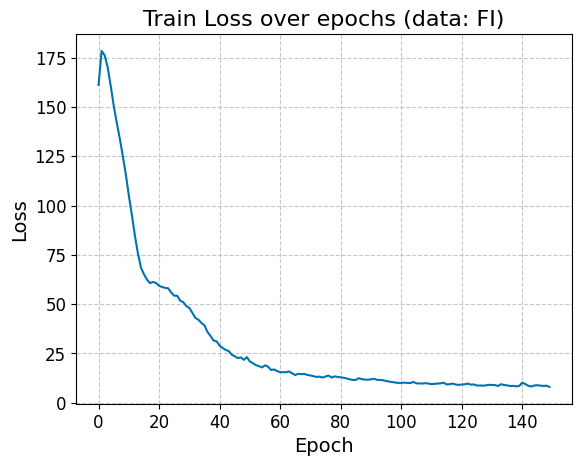

In [69]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

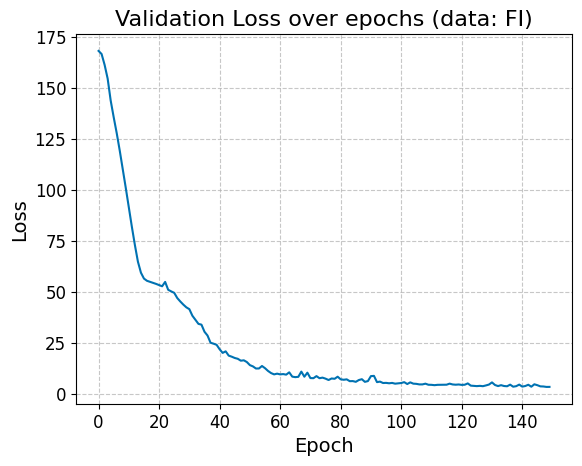

In [70]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [71]:
from anomaly_detection.utils.autoencoders import HistDataset
full_dataset = HistDataset(DATASET_FULL)

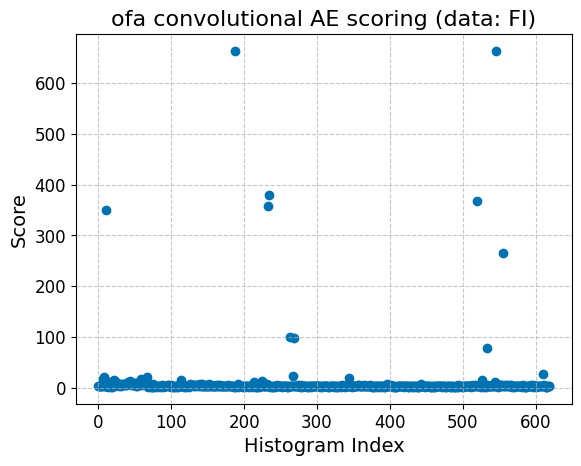

In [72]:
apply_global_style()
plt.title("ofa convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = ae_conv(pt.reshape(1, 1, pt.shape[-1]))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [73]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1, 1, data.shape[-1])).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 619 unique representations that model outputs


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_25752\4226595816.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()
C:\Users\hrdyj\AppData\Local\Temp\ipykernel_25752\4226595816.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = criterion(pred, torch.tensor(full_dataset[idx]))


tensor(5.3159)


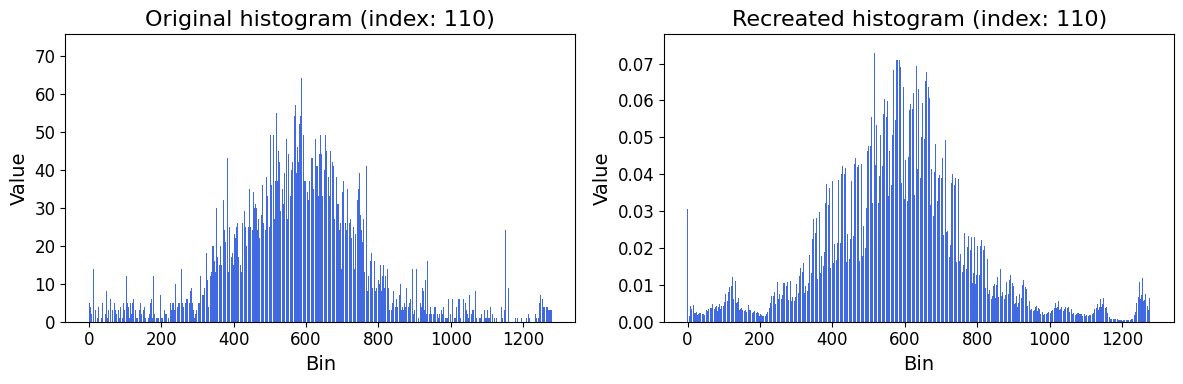

In [74]:
idx = 110

ae_conv.eval()

pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()

criterion = wasserstein_1d_loss

loss = criterion(pred, torch.tensor(full_dataset[idx]))
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_25752\2903757881.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()
C:\Users\hrdyj\AppData\Local\Temp\ipykernel_25752\2903757881.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = criterion(pred, torch.tensor(full_dataset[idx]))


tensor(2.8482)


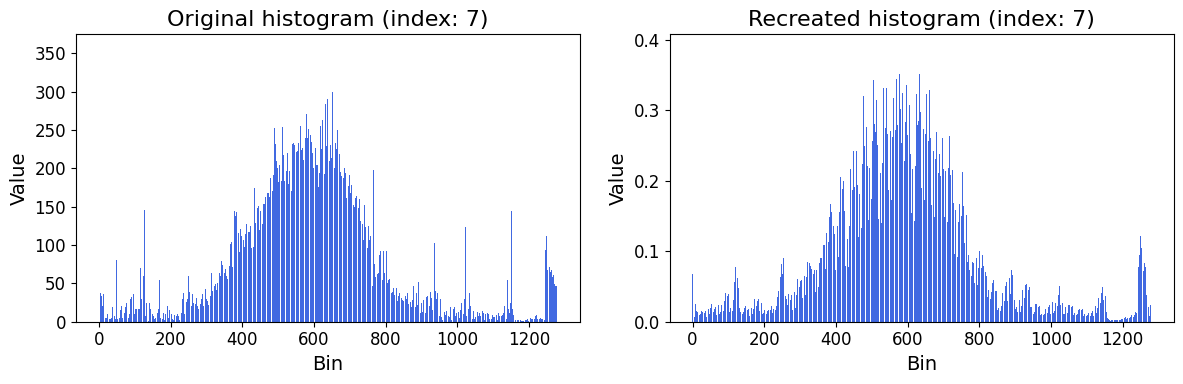

In [76]:
idx = 7

ae_conv.eval()

pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()

criterion = wasserstein_1d_loss

loss = criterion(pred, torch.tensor(full_dataset[idx]))
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()